C:\Users\mchen\AppData\Local\Temp\ipykernel_888\730166017.py:6: DtypeWarning: Columns (0: LANE_CNT) have mixed types. Specify dtype option on import or set low_memory=False.
  crashes = pd.read_csv("Traffic_Crashes_-_Crashes_20260922.csv")


         date  hour
0  2020-07-28    21
1  2020-08-12    18
2  2020-08-09     1
3  2020-07-27     9
4  2020-08-10    16
         date  hour
0  2017-01-01  17.0
1  2017-01-01  13.0
2  2017-01-01  15.0
3  2017-01-01  18.0
4  2017-01-01  16.0
             crashes  departures
crashes     1.000000    0.166811
departures  0.166811    1.000000


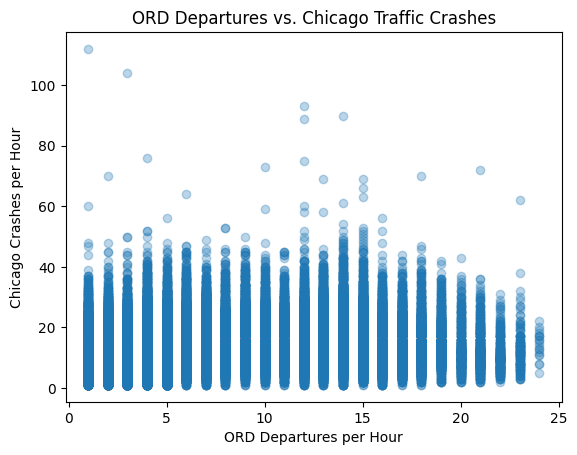

In [12]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

# Open csvs
crashes = pd.read_csv("Traffic_Crashes_-_Crashes_20260922.csv")
flights = pd.read_csv("airline.csv")

#print(crashes.columns)
#print(flights.columns)


# Clean crashes data
crashes["CRASH_DATE"] = pd.to_datetime(
    crashes["CRASH_DATE"],
    format="mixed"
)

# Extract date and hour for later use
crashes["date"] = crashes["CRASH_DATE"].dt.date
crashes["hour"] = crashes["CRASH_HOUR"]


# Clean flights data
flights["Date (MM/DD/YYYY)"] = pd.to_datetime(
    flights["Date (MM/DD/YYYY)"]
)

flights["date"] = flights["Date (MM/DD/YYYY)"].dt.date

flights["hour"] = pd.to_numeric(
    flights["Scheduled departure time"].astype(str).str[:2],
    errors="coerce"
)


# Group by hourly (for merging)
crash_hourly = (
    crashes
    .groupby(["date", "hour"])
    .size()
    .reset_index(name="crashes")
)

flight_hourly = (
    flights
    .groupby(["date", "hour"])
    .size()
    .reset_index(name="departures")
)

print(crashes[["date", "hour"]].head())
print(flights[["date", "hour"]].head())


# Merge both hourly sets together

integrated = pd.merge(
    crash_hourly,
    flight_hourly,
    on=["date", "hour"],
    how="inner"
)

# Print correlation
print(integrated[["crashes", "departures"]].corr())

# Create scatter plot to visualize correlation
plt.scatter(integrated["departures"], integrated["crashes"], alpha=0.3)
plt.xlabel("ORD Departures per Hour")
plt.ylabel("Chicago Crashes per Hour")
plt.title("ORD Departures vs. Chicago Traffic Crashes")
plt.show()